Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: LGBMClassifier
Composite features: ['attendance_risk_index', 'socioeconomic_vulnerability_score', 'behavioral_engagement_index']
Test Samples: (200, 41)
Target Samples: (200,)
SHAP values calculated and saved (raw log-odds space).


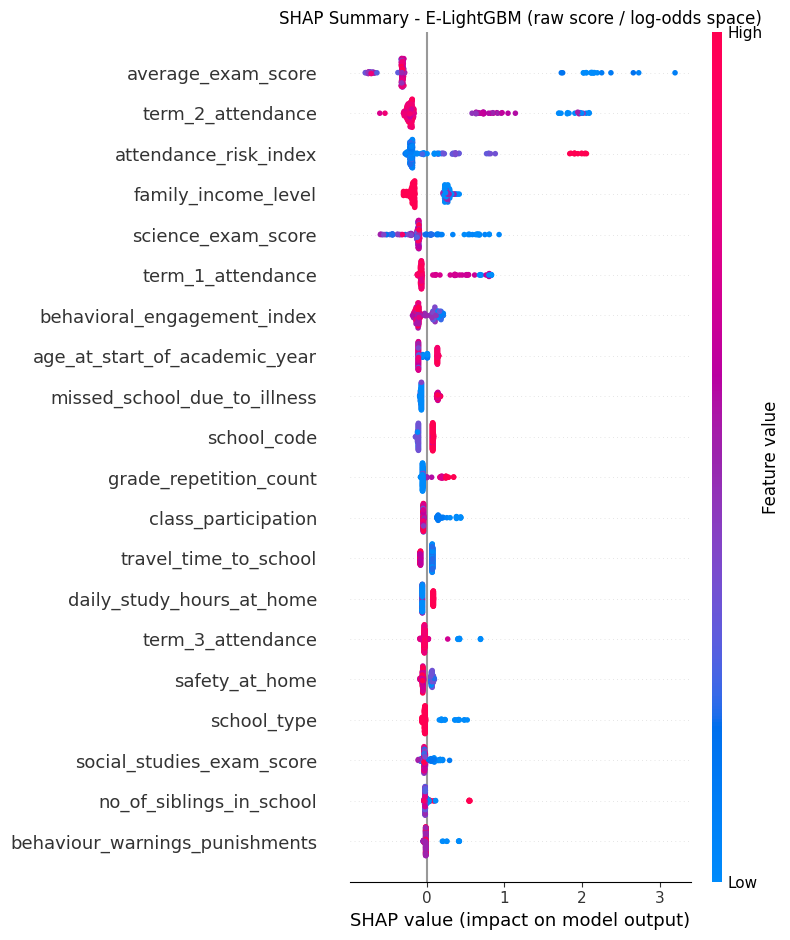

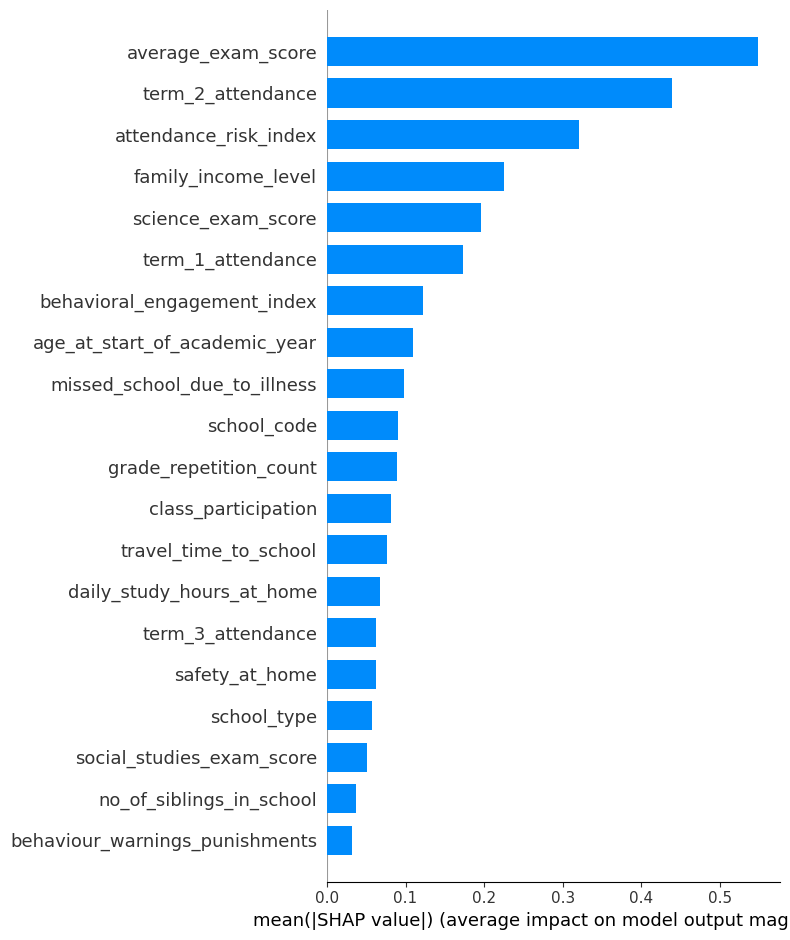

,Feature,Mean_Abs_SHAP,Is_Composite,Rank
0,average_exam_score,0.548664,False,1
1,term_2_attendance,0.438691,False,2
2,attendance_risk_index,0.320528,True,3
3,family_income_level,0.225317,False,4
4,science_exam_score,0.195537,False,5
5,term_1_attendance,0.173500,False,6
6,behavioral_engagement_index,0.121690,True,7
7,age_at_start_of_academic_year,0.109045,False,8
8,missed_school_due_to_illness,0.098376,False,9
9,school_code,0.090220,False,10


Feature importance table saved: feature_importance_focal.csv

Composite feature ranks:


,Rank,Feature,Mean_Abs_SHAP
2,3,attendance_risk_index,0.320528
6,7,behavioral_engagement_index,0.121690
23,24,socioeconomic_vulnerability_score,0.017391


All 3 composite features ranked within the top 24 predictors.
Explaining pupil at index 187
Predicted dropout probability: 0.9947
Actual label: 1


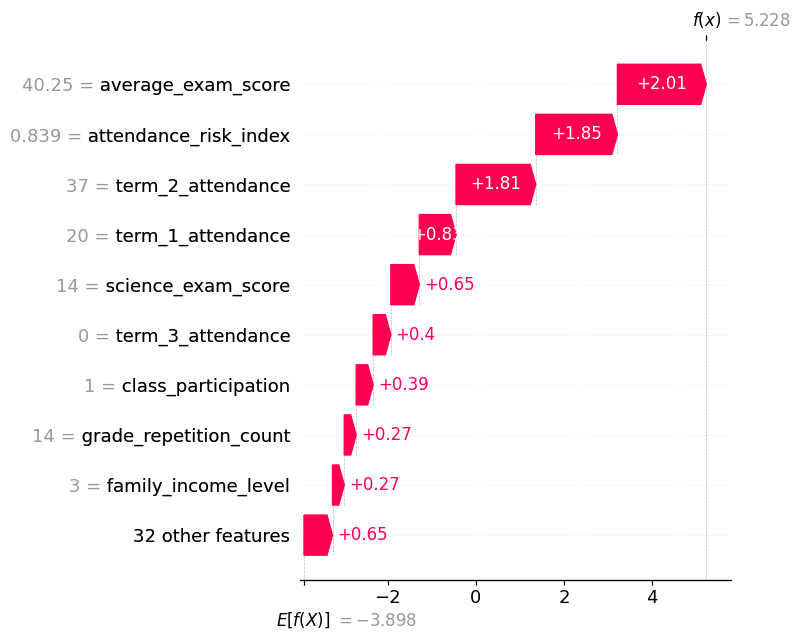

Dependence plot feature: attendance_risk_index


<Figure size 640x480 with 0 Axes>

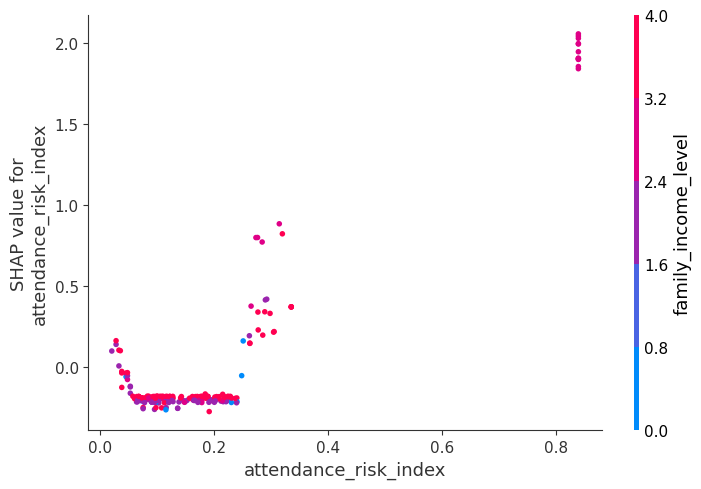

NOTEBOOK 7 (FOCAL) COMPLETE
SHAP values saved: shap_values_focal.pkl
Feature importance saved: feature_importance_focal.csv
Figures saved:
 - shap_summary_focal.png
 - shap_bar_focal.png
 - waterfall_focal.png
 - dependence_plot_focal.png

NOTE: SHAP values here are in RAW LOG-ODDS space (model_output='raw'), not probability space, because E-LightGBM's predict_proba()
is not valid under the custom focal-loss objective. State this explicitly in the Results section figure caption for Figure 6.


In [2]:
# -*- coding: utf-8 -*-
"""Notebook 7 - Explainable AI (SHAP Analysis) for E-LightGBM.ipynb

Explains the E-LightGBM model (Notebook 6b) using SHAP TreeExplainer.
Self-contained: does not depend on an external losses.py module, since
TreeExplainer only needs the trained model object - the objective
function used to train it is already baked into the tree structure and
isn't needed again here. predict_proba_focal() is redefined locally
(two lines) rather than imported, so this notebook has no dependency
on losses.py existing in the right place on Drive.

IMPORTANT: if you keep a losses.py module for Notebook 6b, make sure it
has the corrected argument order - focal_loss_lgb(y_true, y_pred), not
(y_pred, y_true) or (y_pred, dtrain). Reversing it silently swaps the
true labels and the raw prediction scores and causes the model to
collapse to always predicting the majority class.
"""

# Uncomment if running for the first time
# !pip install -q shap joblib

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import shap

from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

MODEL_DIR = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"
FIGURE_DIR = f"{PROJECT_DIR}/figures"
DATA_DIR = f"{PROJECT_DIR}/data"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# ============================================================
# REQUIRED before joblib.load() below - do not remove.
#
# LightGBM pickles a custom `objective` function by reference (module
# name + function name), not by value. e_lightgbm_focal_loss_model.pkl
# was created in Notebook 6b's own kernel, where focal_loss_lgb was
# defined directly in that notebook - so it was pickled as a reference
# to __main__.focal_loss_lgb. This notebook runs in a DIFFERENT kernel
# session with its own separate __main__, which has no such function,
# so joblib.load() fails with AttributeError while trying to resolve
# that reference - it can rebuild the tree ensemble fine, it just
# can't re-bind the objective. Redefining the identical function under
# the identical name here (never actually called anywhere below) lets
# pickle resolve it. Must match Notebook 6b's implementation exactly.
# ============================================================

GAMMA = 2.0
ALPHA = 0.75
EPSILON = 1e-6

def focal_loss_lgb(y_true, y_pred):
    p = 1.0 / (1.0 + np.exp(-y_pred))
    p = np.clip(p, EPSILON, 1.0 - EPSILON)
    pt = np.where(y_true == 1, p, 1.0 - p)
    alpha_t = np.where(y_true == 1, ALPHA, 1.0 - ALPHA)
    grad = alpha_t * (1.0 - pt) ** GAMMA * (p - y_true)
    hess = alpha_t * (1.0 - pt) ** GAMMA * p * (1.0 - p)
    return grad, hess

def focal_loss_eval(y_true, y_pred):
    p = 1.0 / (1.0 + np.exp(-y_pred))
    p = np.clip(p, 1e-7, 1 - 1e-7)
    pt = np.where(y_true == 1, p, 1.0 - p)
    alpha_t = np.where(y_true == 1, ALPHA, 1.0 - ALPHA)
    loss = -alpha_t * (1.0 - pt) ** GAMMA * np.log(pt)
    return "focal_loss", float(np.mean(loss)), False

# ============================================================
# Load the E-LightGBM Model and Config
# ============================================================

model = joblib.load(f"{MODEL_DIR}/e_lightgbm_focal_loss_model.pkl")

config = joblib.load(f"{MODEL_DIR}/e_lightgbm_config.pkl")

composite_features = config["composite_features"]

print("Model:", type(model).__name__)
print("Composite features:", composite_features)

def predict_proba_focal(model, X_eval):
    # LightGBM's built-in .predict_proba() does NOT work correctly
    # under a custom objective (it returns raw logits, not calibrated
    # probabilities) - always use this instead.
    raw_scores = model.predict(X_eval, raw_score=True)
    return 1.0 / (1.0 + np.exp(-raw_scores))

# ============================================================
# Load Test Data
# ============================================================

# Saved directly by Notebook 6b from the same split used to train and
# evaluate every LightGBM variant. E-LightGBM uses the FULL feature
# set (raw + composite), so no column subsetting is needed here.
X_test = pd.read_csv(f"{DATA_DIR}/X_test_focal.csv")

y_test = pd.read_csv(f"{DATA_DIR}/y_test_focal.csv").squeeze()

print("Test Samples:", X_test.shape)
print("Target Samples:", y_test.shape)

# ============================================================
# Create TreeExplainer
# ============================================================

# model_output="raw" is required here: E-LightGBM's predict_proba() is
# not meaningful under a custom objective, so SHAP must explain the
# raw margin/log-odds output directly.
explainer = shap.TreeExplainer(model, model_output="raw")

# ============================================================
# Calculate SHAP Values
# ============================================================

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

feature_names = X_test.columns.tolist()

joblib.dump(
    {
        "shap_values": shap_values,
        "feature_names": feature_names,
        "X_test": X_test,
        "output_space": "raw_log_odds"
    },
    f"{MODEL_DIR}/shap_values_focal.pkl"
)

print("SHAP values calculated and saved (raw log-odds space).")

# ============================================================
# Summary Plot
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values_positive,
    X_test,
    show=False
)

plt.title("SHAP Summary - E-LightGBM (raw score / log-odds space)")
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/shap_summary_focal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Bar Plot (Global Feature Importance)
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values_positive,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/shap_bar_focal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Feature Importance Table
# ============================================================

mean_abs_shap = np.abs(shap_values_positive).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

feature_importance_df["Is_Composite"] = feature_importance_df["Feature"].isin(composite_features)

feature_importance_df["Rank"] = feature_importance_df.index + 1

display(feature_importance_df.head(20))

feature_importance_df.to_csv(
    f"{RESULT_DIR}/feature_importance_focal.csv",
    index=False
)

print("Feature importance table saved: feature_importance_focal.csv")

composite_ranks = feature_importance_df[feature_importance_df["Is_Composite"]]

print()
print("Composite feature ranks:")
display(composite_ranks[["Rank", "Feature", "Mean_Abs_SHAP"]])

if len(composite_ranks) > 0:
    max_rank = composite_ranks["Rank"].max()
    print(f"All {len(composite_ranks)} composite features ranked within "
          f"the top {max_rank} predictors.")

# ============================================================
# Waterfall Plot (Local Explanation)
# ============================================================

# Explain the single test-set pupil with the highest predicted dropout
# risk. Ranking by raw score is equivalent to ranking by probability
# since sigmoid is monotonic, so no need to compute probabilities
# first just to find the argmax.
raw_scores = model.predict(X_test, raw_score=True)

highest_risk_idx = int(np.argmax(raw_scores))

predicted_prob = predict_proba_focal(model, X_test.iloc[[highest_risk_idx]])[0]

print(f"Explaining pupil at index {highest_risk_idx}")
print(f"Predicted dropout probability: {predicted_prob:.4f}")
print(f"Actual label: {y_test.iloc[highest_risk_idx]}")

single_explanation = shap.Explanation(
    values=shap_values_positive[highest_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[highest_risk_idx].values,
    feature_names=feature_names
)

plt.figure()

shap.plots.waterfall(single_explanation, show=False)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/waterfall_focal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Dependence Plot
# ============================================================

dependence_feature = (
    "attendance_risk_index"
    if "attendance_risk_index" in feature_names
    else feature_names[0]
)

print(f"Dependence plot feature: {dependence_feature}")

plt.figure()

shap.dependence_plot(
    dependence_feature,
    shap_values_positive,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/dependence_plot_focal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Notebook Summary
# ============================================================

print("=" * 60)
print("NOTEBOOK 7 (FOCAL) COMPLETE")
print("=" * 60)

print("SHAP values saved: shap_values_focal.pkl")
print("Feature importance saved: feature_importance_focal.csv")
print("Figures saved:")
print(" - shap_summary_focal.png")
print(" - shap_bar_focal.png")
print(" - waterfall_focal.png")
print(" - dependence_plot_focal.png")
print()
print("NOTE: SHAP values here are in RAW LOG-ODDS space (model_output="
      "'raw'), not probability space, because E-LightGBM's predict_proba()")
print("is not valid under the custom focal-loss objective. State this "
      "explicitly in the Results section figure caption for Figure 6.")
